# Validación Cruzada y opitimización de hiperparametros

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from time import perf_counter

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

In [2]:
housing = fetch_california_housing(as_frame  = True)
X = housing.data
y= housing.target

X_train, X_test, y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42
)

modelo = GradientBoostingRegressor(
    n_estimators = 200,
    learning_rate = 0.5,
    max_depth = 2,
    random_state = 42
)

resultados_split = []

for semilla in [1, 10, 42, 100, 500]:

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train,
        y_train,
        test_size=0.20,
        random_state=semilla
    )

    modelo.fit(X_tr, y_tr)

    pred = modelo.predict(X_val)

    rmse = np.sqrt(
        mean_squared_error(y_val, pred)
    )

    resultados_split.append({
        "random_state": semilla,
        "RMSE": rmse
    })

df_split = pd.DataFrame(resultados_split)

df_split

,random_state,RMSE
0,1,0.515456
1,10,0.510848
2,42,0.514444
3,100,0.496784
4,500,0.503796


In [3]:
cv = KFold(n_splits = 2,
          shuffle= True,
          random_state = 42)

modelo = GradientBoostingRegressor(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 2,
    random_state = 42
)

scores = cross_val_score(
    modelo,
    X_train,
    y_train,
    cv = cv,
    scoring = "neg_root_mean_squared_error"
)

scores
rmse_cv = -scores
print(rmse_cv.mean())
print(rmse_cv.std())



0.5790988564440334
0.006332123923391275


In [4]:
print(
    f"RMSE CV: {rmse_cv.mean():.4f} "
    f"+/- {rmse_cv.std():.4f}"
)

RMSE CV: 0.5791 +/- 0.0063


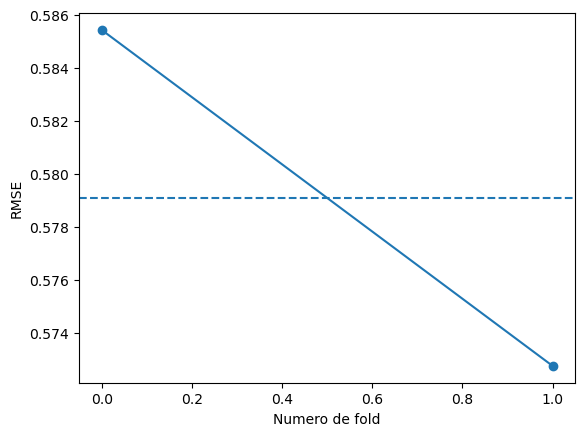

In [6]:
plt.figure()
plt.plot(range(0,2),rmse_cv, marker = "o")
plt.axhline(rmse_cv.mean(),linestyle ="--")
plt.xlabel("Numero de fold")
plt.ylabel("RMSE")
plt.show()

In [7]:
configuraciones = [
    ("A", 0.1, 100, 2),
    ("B", 0.05, 200, 2),
    ("C", 0.01, 500, 2),
    ("D", 0.1, 100, 4)
]

resultados_cv = []
for nombre, lr, n_est, depth in configuraciones:
    modelo = GradientBoostingRegressor(
        learning_rate = lr,
        n_estimators = n_est,
        max_depth = depth,
        random_state = 42
    )
    scores = cross_val_score(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring = "neg_root_mean_squared_error"
        
    )
    rmse = -scores
    resultados_cv.append(
        {
            "Modelo": nombre,
            "learning_rate": lr,
            "n_stimators": n_est,
            "marx_depth": depth,
            "RMSE_CV": rmse.mean(),
            "SD_CV": rmse.std()
        }
    )
df_cv = pd.DataFrame(resultados_cv)
df_cv

,Modelo,learning_rate,n_stimators,marx_depth,RMSE_CV,SD_CV
0,A,0.10,100,2,0.575934,0.004638
1,B,0.05,200,2,0.579099,0.006332
2,C,0.01,500,2,0.641487,0.012018
3,D,0.10,100,4,0.513558,0.005260


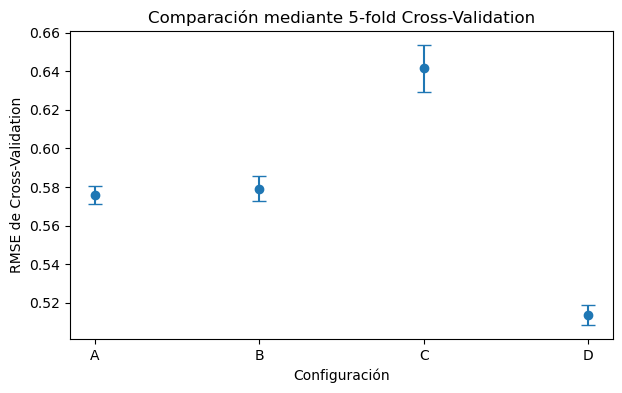

In [8]:
plt.figure(figsize=(7, 4))

plt.errorbar(
    df_cv["Modelo"],
    df_cv["RMSE_CV"],
    yerr=df_cv["SD_CV"],
    fmt="o",
    capsize=5
)

plt.xlabel("Configuración")
plt.ylabel("RMSE de Cross-Validation")
plt.title("Comparación mediante 5-fold Cross-Validation")
plt.show()

In [16]:
param_grid = {
    "learning_rate": [0.01,0.05,0.1],
    "n_estimators": [100,200,500],
    "max_depth": [2,3,4]
}

modelo = GradientBoostingRegressor(random_state = 42)
grid_search = GridSearchCV(
    estimator = modelo,
    param_grid=param_grid,
    scoring = "neg_root_mean_squared_error",
    cv = cv,
    n_jobs = -1,
    return_train_score = True
)

grid_search

GridSearchCV(cv=KFold(n_splits=2, random_state=42, shuffle=True),
             estimator=GradientBoostingRegressor(random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [2, 3, 4],
                         'n_estimators': [100, 200, 500]},
             return_train_score=True, scoring='neg_root_mean_squared_error')

In [17]:
inicio  = perf_counter()
grid_search.fit(X_train, y_train)
tiempo_grid = perf_counter() - inicio
print(f"{tiempo_grid:.2f} en segundos")

92.22 en segundos


Exception ignored in: <function ResourceTracker.__del__ at 0x76ebb1586020>
Traceback (most recent call last):
  File "/home/gdiek/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/gdiek/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/gdiek/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x765c41782020>
Traceback (most recent call last):
  File "/home/gdiek/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/gdiek/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/gdiek/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ 

In [20]:
grid_search.best_params_
grid_search.best_score_

np.float64(-0.4858481048023472)

In [21]:
best_rmse_grid = - grid_search.best_score_
best_rmse_grid

np.float64(0.4858481048023472)

In [23]:
grid_search.best_estimator_

GradientBoostingRegressor(max_depth=4, n_estimators=500, random_state=42)

In [26]:
resultados_grid = pd.DataFrame(
    grid_search.cv_results_
)

resultados_grid.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,mean_train_score,std_train_score
0,2.082210,0.011581,0.017087,0.000189,0.01,2,100,"{'learning_rate': 0.01, 'max_depth': 2, 'n_est...",-0.883478,-0.861354,-0.872416,0.011062,27,-0.857187,-0.875713,-0.866450,0.009263
1,4.081623,0.000652,0.030288,0.000106,0.01,2,200,"{'learning_rate': 0.01, 'max_depth': 2, 'n_est...",-0.784386,-0.761459,-0.772922,0.011463,24,-0.756187,-0.771701,-0.763944,0.007757
2,10.263797,0.015582,0.067657,0.000393,0.01,2,500,"{'learning_rate': 0.01, 'max_depth': 2, 'n_est...",-0.653505,-0.629469,-0.641487,0.012018,21,-0.624631,-0.630851,-0.627741,0.003110
3,3.045768,0.014767,0.023543,0.000180,0.01,3,100,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",-0.823858,-0.802188,-0.813023,0.010835,26,-0.795916,-0.810165,-0.803040,0.007125
4,6.105947,0.004272,0.043992,0.000245,0.01,3,200,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",-0.707254,-0.693911,-0.700582,0.006672,23,-0.677114,-0.693228,-0.685171,0.008057


In [29]:
columnas = [
    "param_learning_rate",
    "param_n_estimators",
    "param_max_depth",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
    "mean_fit_time"
]

resultados_grid[columnas].head()

,param_learning_rate,param_n_estimators,param_max_depth,mean_test_score,std_test_score,rank_test_score,mean_fit_time
0,0.01,100,2,-0.872416,0.011062,27,2.082210
1,0.01,200,2,-0.772922,0.011463,24,4.081623
2,0.01,500,2,-0.641487,0.012018,21,10.263797
3,0.01,100,3,-0.813023,0.010835,26,3.045768
4,0.01,200,3,-0.700582,0.006672,23,6.105947


In [33]:
resultados_grid[
    [
        "param_learning_rate",
        "param_n_estimators",
        "param_max_depth",
        "RMSE_CV",
        "std_test_score",
        "mean_fit_time"
    ]
].sort_values("RMSE_CV").head(10)

,param_learning_rate,param_n_estimators,param_max_depth,RMSE_CV,std_test_score,mean_fit_time
26,0.10,500,4,0.485848,0.009376,16.379936
17,0.05,500,4,0.490883,0.007618,19.734837
25,0.10,200,4,0.495461,0.007049,7.220921
23,0.10,500,3,0.497193,0.009137,14.217613
14,0.05,500,3,0.510087,0.007685,14.913432
24,0.10,100,4,0.513558,0.005260,3.953189
16,0.05,200,4,0.513898,0.005658,7.824864
22,0.10,200,3,0.514769,0.006997,5.983346
20,0.10,500,2,0.516003,0.008125,10.125915
11,0.05,500,2,0.537659,0.008847,10.115000


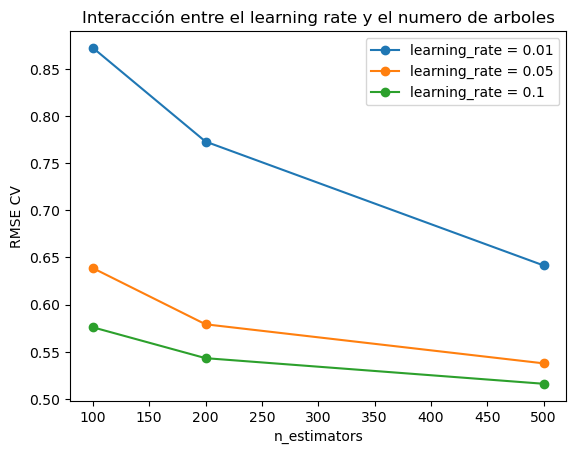

In [38]:
grid_depth2 = resultados_grid[resultados_grid["param_max_depth"]==2].copy()
for lr in sorted(grid_depth2["param_learning_rate"].unique()):
    datos = grid_depth2[grid_depth2["param_learning_rate"]==lr].sort_values("param_n_estimators")
    plt.plot(datos["param_n_estimators"],
            datos["RMSE_CV"],
            marker = "o",
            label = f"learning_rate = {lr}")

plt.xlabel("n_estimators")
plt.ylabel("RMSE CV")
plt.title("Interacción entre el learning rate y el numero de arboles")
plt.legend()
plt.show()